In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ceres = xr.open_dataset(r"D://Niharika Work//Climate_Project//CERES_EBAF-TOA_Edition4.1-20260303_075023//CERES_EBAF-TOA_Edition4.1_200003-202203.nc")

In [3]:
era5 = xr.open_dataset("D://Niharika Work//Climate_Project//ERA5_temperature/ceb0d88e509872628f04434b2a0c5d5d.nc")

In [4]:
T = era5.rename({"valid_time":"time"})

In [5]:
T = T["t2m"].sel(time=slice("2001","2014"))

### Compute Global Mean Temperature

In [6]:
import numpy as np

weights = np.cos(np.deg2rad(T.latitude))

T_global = T.weighted(weights).mean(("latitude","longitude"))

### Compute CERES Radiation

In [7]:
R = ceres['toa_net_all_mon']

weights = np.cos(np.deg2rad(ceres.lat))

R_global = R.weighted(weights).mean(("lat","lon"))

In [8]:
# Convert to DataFrame

T_df = T_global.to_dataframe(name="T")
R_df = R_global.to_dataframe(name="R")

In [9]:
# Extract year and month

T_df["year"] = T_df.index.year
T_df["month"] = T_df.index.month

R_df["year"] = R_df.index.year
R_df["month"] = R_df.index.month

In [10]:
# Merge the datasets

merged = T_df.merge(R_df, on=["year", "month"])

In [11]:
print(len(merged))

168


### Compute Anomalies

In [12]:
# Remove seasonal cycle

merged["T_anom"] = merged["T"] - merged.groupby("month")["T"].transform("mean")
merged["R_anom"] = merged["R"] - merged.groupby("month")["R"].transform("mean")

### Compute Feedback λ

In [13]:
lambda_feedback = np.polyfit(
    merged["T_anom"],
    merged["R_anom"],
    1
)[0]

print("Observed feedback λ =", lambda_feedback, "W m^-2 K^-1")

Observed feedback λ = -1.0477615014825876 W m^-2 K^-1


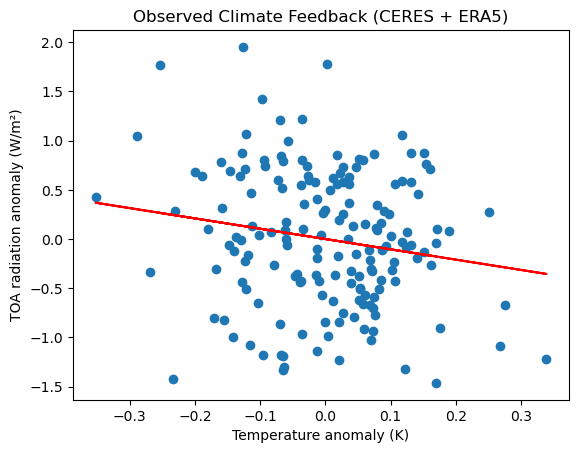

In [14]:
import matplotlib.pyplot as plt

plt.scatter(merged["T_anom"], merged["R_anom"])

fit = np.polyfit(merged["T_anom"], merged["R_anom"], 1)
plt.plot(merged["T_anom"], fit[0]*merged["T_anom"] + fit[1], color="red")

plt.xlabel("Temperature anomaly (K)")
plt.ylabel("TOA radiation anomaly (W/m²)")
plt.title("Observed Climate Feedback (CERES + ERA5)")

plt.show()

In [15]:
# import matplotlib.pyplot as plt

# plt.scatter(merged["T_anom"], merged["R_anom"], alpha=0.6)

# fit = np.polyfit(merged["T_anom"], merged["R_anom"], 1)

# x = merged["T_anom"]
# plt.plot(x, fit[0]*x + fit[1], color="red")

# plt.xlabel("Temperature anomaly (K)")
# plt.ylabel("TOA radiation anomaly (W/m²)")
# plt.title("Observed Climate Feedback (CERES + ERA5)")

# plt.show()